# Chapter 3: Dimensionality Reduction

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Learn why and how to reduce high-dimensional data using linear projection and manifold learning on MNIST (Modified National Institute of Standards and Technology) handwritten digits.

---

## What you will learn

1. Why dimensionality reduction matters — the **curse of dimensionality**
2. Load and explore the MNIST digits database (pixels, shapes, sample images)
3. **Linear projection** vs **manifold learning** (nonlinear structure)
4. **PCA (Principal Component Analysis):** variance explained, 2D scatter, inverse transform
5. **Gaussian Random Projection** and **Sparse Random Projection**
6. Brief **t-SNE (t-Distributed Stochastic Neighbor Embedding)** demo for visualization
7. Compare reduction methods in one summary table


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Plots — bar charts, scatter plots, digit images |
| **scikit-learn (Scientific Kit for Learning)** | PCA, random projection, t-SNE, scaling |
| **IPython (Interactive Python)** | Rich display in Jupyter (Julia, Python, and R notebook environment) |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import time module to measure how long each reduction method takes
import time

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import MNIST (Modified National Institute of Standards and Technology) loader and digit fallback
from sklearn.datasets import fetch_openml, load_digits

# Import StandardScaler to put pixel features on comparable scale
from sklearn.preprocessing import StandardScaler

# Import PCA (Principal Component Analysis) for linear dimensionality reduction
from sklearn.decomposition import PCA

# Import random projection algorithms from Chapter 3
from sklearn.random_projection import GaussianRandomProjection, SparseRandomProjection

# Import t-SNE (t-Distributed Stochastic Neighbor Embedding) for nonlinear visualization
from sklearn.manifold import TSNE

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Store MNIST pixels and reduced coordinates |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Explore data with `.describe()` and summary tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | Variance bars, 2D scatters, digit images |
| **sklearn.datasets** | Built-in datasets | Load MNIST (Modified National Institute of Standards and Technology) digits |
| **sklearn.preprocessing.StandardScaler** | Feature scaling | Normalize pixels before PCA (Principal Component Analysis) |
| **sklearn.decomposition.PCA** | Linear dimensionality reduction | Compress 784 pixels while keeping variance |
| **sklearn.random_projection** | Fast random linear projections | Gaussian and sparse alternatives to PCA |
| **sklearn.manifold.TSNE** | Nonlinear manifold learning | Visualize digit clusters in 2D (two-dimensional) |


---

## Algorithms Used in This Notebook

### 1. PCA (Principal Component Analysis) (`PCA`)
- **Type:** Linear projection — finds directions of maximum variance
- **Output:** New axes (principal components) ranked by variance explained
- **Key hyperparameters:** `n_components`, `random_state`
- **Inverse transform:** Reconstruct approximate original pixels from reduced space

### 2. Gaussian Random Projection (`GaussianRandomProjection`)
- **Type:** Linear projection using a dense random matrix with Gaussian entries
- **Finds:** A quick low-dimensional sketch of the data (Johnson-Lindenstrauss lemma)
- **Key hyperparameters:** `n_components`, `random_state`

### 3. Sparse Random Projection (`SparseRandomProjection`)
- **Type:** Linear projection using a sparse random matrix (faster on very wide data)
- **Finds:** Similar goal to Gaussian version with fewer stored weights
- **Key hyperparameters:** `n_components`, `density`, `random_state`

### 4. t-SNE (t-Distributed Stochastic Neighbor Embedding) (`TSNE`)
- **Type:** Manifold learning — nonlinear dimensionality reduction
- **Finds:** 2D (two-dimensional) layout that preserves local neighborhoods
- **Warning:** Slow on large samples; we use a subsample of 1,500 images
- **Key hyperparameters:** `n_components`, `perplexity`, `random_state`

### Evaluation note (important for beginners)

Dimensionality reduction is **unsupervised** — algorithms never see digit labels during fitting. We color plots by true digit **only to help you interpret** whether separated groups make sense.


---

## 1. Motivation — Curse of Dimensionality

Each MNIST image has **784 pixel features** (28×28 grid). In high dimensions:

- Points become **sparse** — most of the space is empty
- Distances become less meaningful (all points look similarly far apart)
- Models need **more data** to learn reliably
- Storage and compute costs grow quickly

**Dimensionality reduction** compresses many features into fewer while keeping useful structure — faster algorithms, easier visualization, and often better generalization.

| Problem in high dimensions | How reduction helps |
|---------------------------|---------------------|
| Too many features per image | Fewer components capture most variation |
| Hard to plot 784 axes | 2D (two-dimensional) scatter reveals clusters |
| Slow downstream ML (Machine Learning) | Smaller matrices train faster |


---

## 2. MNIST (Modified National Institute of Standards and Technology) Data

The book uses **MNIST handwritten digits**: 28×28 grayscale images (784 pixels), labels 0–9.

We load **5,000 samples** from OpenML `mnist_784` for teaching speed. If download fails, we fall back to `load_digits` (smaller 8×8 digits).


In [2]:
# Set random seed so subsampling and projections are reproducible
RANDOM_STATE = 2018

# Number of MNIST samples to use (subset for faster teaching demos)
N_SAMPLES = 5000

# Try to download MNIST 784 features from OpenML (online ML repository)
try:

    print("Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...")

    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

    X_full = mnist.data.astype(np.float64)

    y_full = mnist.target.astype(int)

    rng = np.random.RandomState(RANDOM_STATE)

    idx = rng.choice(len(y_full), size=N_SAMPLES, replace=False)

    X_raw = X_full[idx]

    y = y_full[idx]

    DATA_SOURCE = "MNIST 784 (subset)"

except Exception as e:

    print(f"MNIST download failed ({e}). Using sklearn load_digits fallback.")

    digits = load_digits()

    X_raw = digits.data.astype(np.float64)

    y = digits.target.astype(int)

    DATA_SOURCE = "load_digits (8x8 fallback)"

# Report dataset shape: rows = images, columns = pixels
print(f"Data source: {DATA_SOURCE}")

print(f"X shape: {X_raw.shape}  |  unique digit labels: {np.unique(y)}")


Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...
Data source: MNIST 784 (subset)
X shape: (5000, 784)  |  unique digit labels: [0 1 2 3 4 5 6 7 8 9]


---

## 3. Explore Data — Shape, Describe, Sample Images


In [3]:
# Build a pandas DataFrame (two-dimensional labeled data table) for exploration
feature_cols = [f"pixel_{i}" for i in range(X_raw.shape[1])]

X_df = pd.DataFrame(X_raw, columns=feature_cols)

y_series = pd.Series(y, name="digit")

# Show first rows — each row is one digit image flattened to pixels
display(X_df.head())

# Summary statistics for pixel values (min, max, mean, std, etc.)
print("Pixel value summary (first 5 features shown):")

display(X_df.iloc[:, :5].describe().T)

# Class balance — MNIST digits are roughly balanced
print("Samples per digit:")

print(y_series.value_counts().sort_index())


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Pixel value summary (first 5 features shown):


,count,mean,std,min,25%,50%,75%,max
pixel_0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pixel_1,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pixel_2,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pixel_3,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pixel_4,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Samples per digit:
digit
0    529
1    532
2    521
3    520
4    455
5    431
6    487
7    523
8    489
9    513
Name: count, dtype: int64


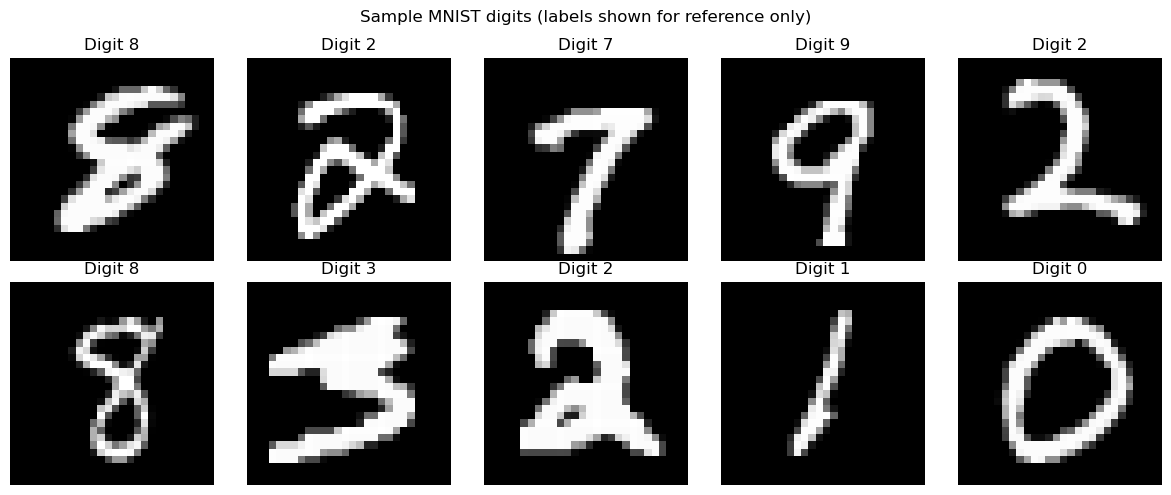

In [4]:
# Visualize sample digit images to connect pixels with handwritten numbers
n_show = 10

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

side = int(np.sqrt(X_raw.shape[1]))

for ax, i in zip(axes.ravel(), range(n_show)):

    ax.imshow(X_raw[i].reshape(side, side), cmap="gray")

    ax.set_title(f"Digit {y[i]}")

    ax.axis("off")

plt.suptitle("Sample MNIST digits (labels shown for reference only)")

plt.tight_layout()

plt.show()


---

## 4. Linear Projection vs Manifold Learning

| Approach | Idea | Examples in this notebook |
|----------|------|---------------------------|
| **Linear projection** | New axes are weighted sums of original features | PCA (Principal Component Analysis), Gaussian/Sparse Random Projection |
| **Manifold learning (nonlinear)** | Data lies on a curved surface in high dimensions | t-SNE (t-Distributed Stochastic Neighbor Embedding) |

**Linear methods** are fast and interpretable (variance, reconstruction). **Manifold methods** can reveal cluster structure for visualization but are slower and mainly for exploration — not always for production feature compression.

We scale pixels before all methods so no single brightness level dominates distances.


In [5]:
# Scale pixel values so PCA (Principal Component Analysis) is not dominated by magnitude
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

# Number of output dimensions used by linear methods in this chapter
N_COMPONENTS = 50

# Number of components for 2D (two-dimensional) visualization scatter plots
N_COMPONENTS_2D = 2

print(f"Scaled data shape: {X_scaled.shape}")

print(f"Linear methods will project to {N_COMPONENTS} dims; plots use {N_COMPONENTS_2D} dims.")


Scaled data shape: (5000, 784)
Linear methods will project to 50 dims; plots use 2 dims.


---

## 5. PCA (Principal Component Analysis)

PCA (Principal Component Analysis) finds orthogonal directions that capture the most variance. We plot **variance explained** per component, a **2D scatter** colored by digit, and demonstrate **inverse transform** (reconstruction).


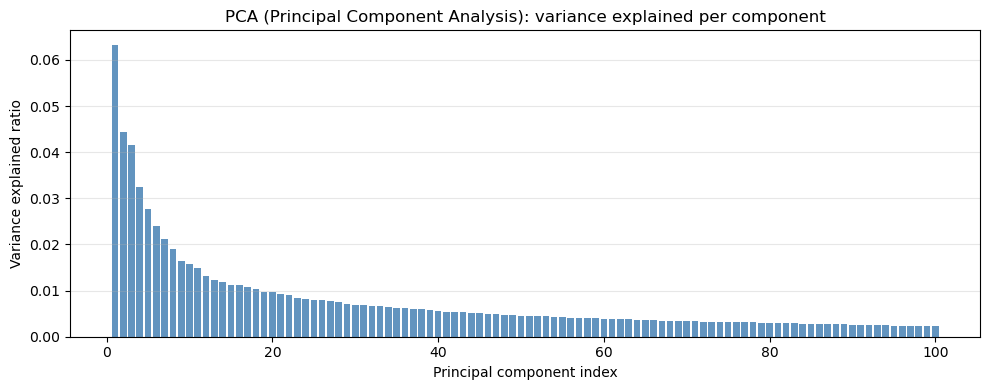

Cumulative variance (first 50 components): 61.3%


In [6]:
# Fit PCA (Principal Component Analysis) with enough components to study variance decay
pca_full = PCA(n_components=min(100, X_scaled.shape[1]), random_state=RANDOM_STATE)

pca_full.fit(X_scaled)

# Bar chart of variance explained by each principal component
var_ratio = pca_full.explained_variance_ratio_

plt.figure(figsize=(10, 4))

plt.bar(range(1, len(var_ratio) + 1), var_ratio, color="steelblue", alpha=0.85)

plt.xlabel("Principal component index")

plt.ylabel("Variance explained ratio")

plt.title("PCA (Principal Component Analysis): variance explained per component")

plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# Report cumulative variance for first N_COMPONENTS components
cum_var = var_ratio[:N_COMPONENTS].sum()

print(f"Cumulative variance (first {N_COMPONENTS} components): {cum_var:.1%}")


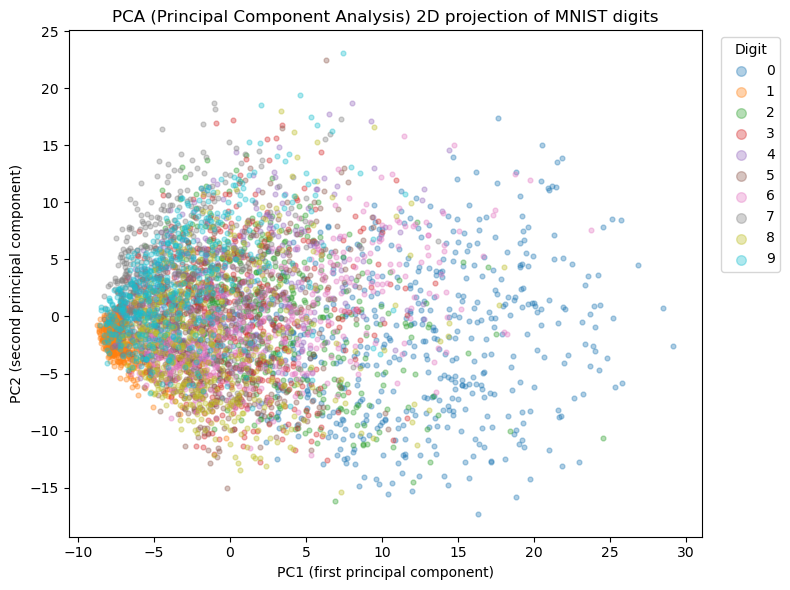

In [7]:
# Fit PCA (Principal Component Analysis) in 2D (two-dimensional) for scatter visualization
pca_2d = PCA(n_components=N_COMPONENTS_2D, random_state=RANDOM_STATE)

X_pca_2d = pca_2d.fit_transform(X_scaled)

# Scatter plot — color by true digit label (for interpretation only)
plt.figure(figsize=(8, 6))

for digit in np.unique(y):

    mask = y == digit

    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=str(digit), alpha=0.35, s=12)

plt.xlabel("PC1 (first principal component)")

plt.ylabel("PC2 (second principal component)")

plt.title("PCA (Principal Component Analysis) 2D projection of MNIST digits")

plt.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2)

plt.tight_layout()

plt.show()


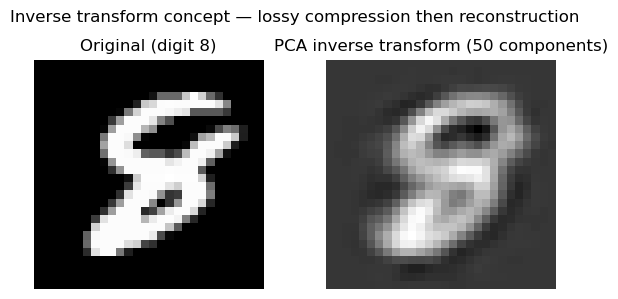

PCA reconstruction MSE (Mean Squared Error) with 50 components: 1224.84


In [8]:
# Demonstrate inverse transform — reconstruct pixels from PCA (Principal Component Analysis) space
pca_recon = PCA(n_components=50, random_state=RANDOM_STATE)

X_pca_recon = pca_recon.fit_transform(X_scaled)

X_reconstructed = pca_recon.inverse_transform(X_pca_recon)

# Inverse transform returns scaled space — map back to original pixel scale for display
X_reconstructed_orig = scaler.inverse_transform(X_reconstructed)

# Compare one original digit with its PCA (Principal Component Analysis) reconstruction
example_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(X_raw[example_idx].reshape(side, side), cmap="gray")

axes[0].set_title(f"Original (digit {y[example_idx]})")

axes[0].axis("off")

axes[1].imshow(X_reconstructed_orig[example_idx].reshape(side, side), cmap="gray")

axes[1].set_title("PCA inverse transform (50 components)")

axes[1].axis("off")

plt.suptitle("Inverse transform concept — lossy compression then reconstruction")

plt.tight_layout()

plt.show()

# Mean squared reconstruction error across all images
recon_mse = np.mean((X_raw - X_reconstructed_orig) ** 2)

print(f"PCA reconstruction MSE (Mean Squared Error) with 50 components: {recon_mse:.2f}")


---

## 6. Gaussian Random Projection

**Gaussian Random Projection** multiplies data by a dense random matrix drawn from a Gaussian distribution. It is a fast alternative when you need fewer dimensions quickly without fitting principal components.


Gaussian Random Projection shape: (5000, 50)
Fit/transform time: 0.015 seconds


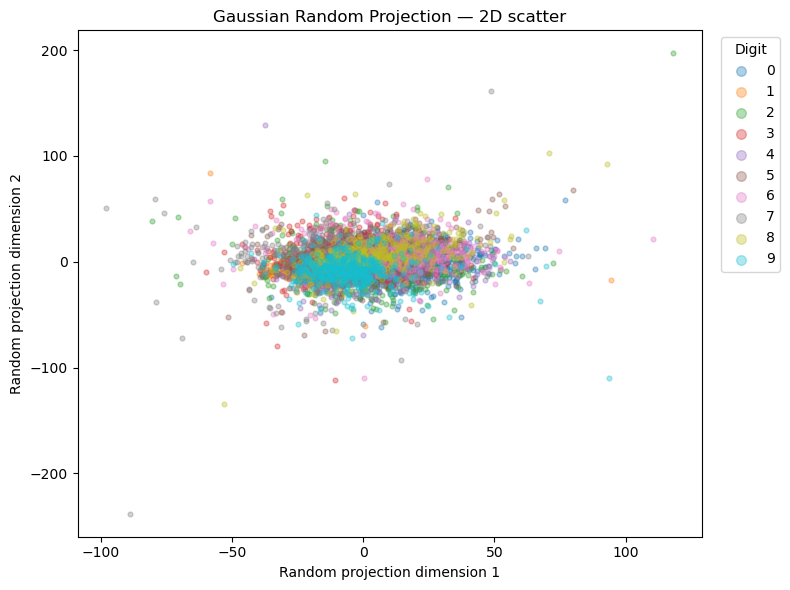

In [9]:
# Time Gaussian Random Projection on scaled MNIST pixels
grp = GaussianRandomProjection(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

t0 = time.perf_counter()

X_grp = grp.fit_transform(X_scaled)

grp_time = time.perf_counter() - t0

print(f"Gaussian Random Projection shape: {X_grp.shape}")

print(f"Fit/transform time: {grp_time:.3f} seconds")

# 2D (two-dimensional) scatter for visual comparison (first 2 projected dimensions)
grp_2d = GaussianRandomProjection(n_components=N_COMPONENTS_2D, random_state=RANDOM_STATE)

X_grp_2d = grp_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for digit in np.unique(y):

    mask = y == digit

    plt.scatter(X_grp_2d[mask, 0], X_grp_2d[mask, 1], label=str(digit), alpha=0.35, s=12)

plt.xlabel("Random projection dimension 1")

plt.ylabel("Random projection dimension 2")

plt.title("Gaussian Random Projection — 2D scatter")

plt.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2)

plt.tight_layout()

plt.show()


---

## 7. Sparse Random Projection

**Sparse Random Projection** uses a sparse random matrix (many zeros). It targets the same Johnson-Lindenstrauss distance-preservation idea with lower memory and faster multiplication on very wide feature spaces.


Sparse Random Projection shape: (5000, 50)
Fit/transform time: 0.086 seconds


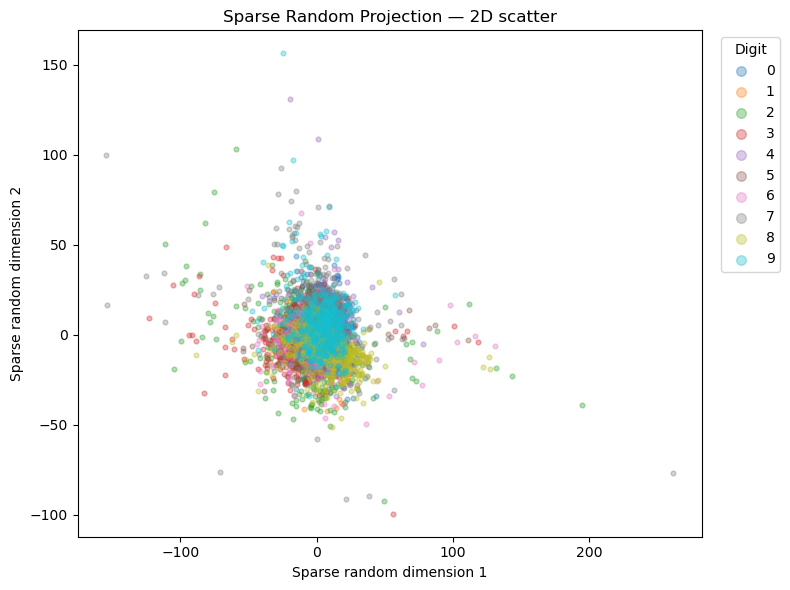

In [10]:
# Time Sparse Random Projection on scaled MNIST pixels
srp = SparseRandomProjection(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

t0 = time.perf_counter()

X_srp = srp.fit_transform(X_scaled)

srp_time = time.perf_counter() - t0

print(f"Sparse Random Projection shape: {X_srp.shape}")

print(f"Fit/transform time: {srp_time:.3f} seconds")

# 2D (two-dimensional) scatter using sparse random projection
srp_2d = SparseRandomProjection(n_components=N_COMPONENTS_2D, random_state=RANDOM_STATE)

X_srp_2d = srp_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for digit in np.unique(y):

    mask = y == digit

    plt.scatter(X_srp_2d[mask, 0], X_srp_2d[mask, 1], label=str(digit), alpha=0.35, s=12)

plt.xlabel("Sparse random dimension 1")

plt.ylabel("Sparse random dimension 2")

plt.title("Sparse Random Projection — 2D scatter")

plt.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2)

plt.tight_layout()

plt.show()


---

## 8. t-SNE (t-Distributed Stochastic Neighbor Embedding) — Brief Demo

> **Warning:** t-SNE is **slow** compared to linear methods. We run it on a **subsample of 1,500** images. Expect this cell to take noticeably longer than PCA or random projection.

t-SNE emphasizes **local neighborhoods** — excellent for visualization, but distances between far-apart clusters are not always meaningful.


Running t-SNE on 1500 samples — please wait (may take 1–3 minutes)...
t-SNE completed in 5.4 seconds


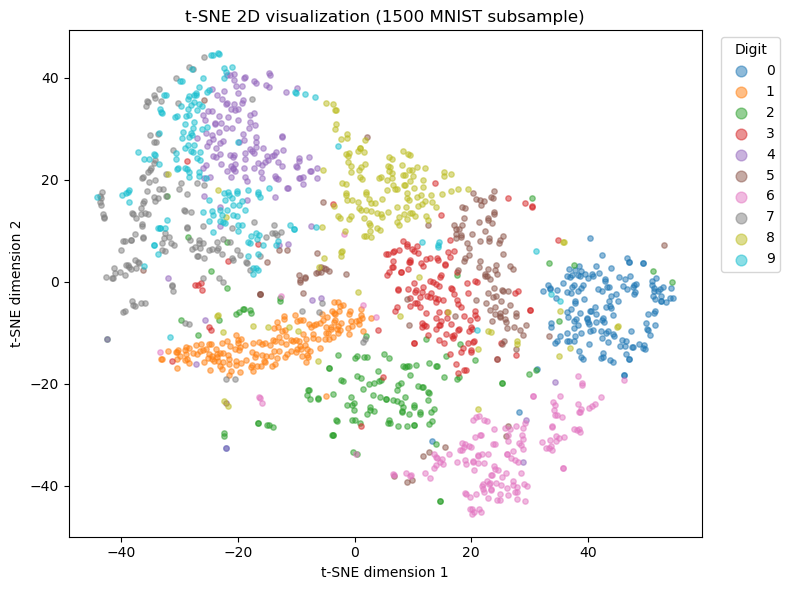

In [11]:
# Subsample for t-SNE (t-Distributed Stochastic Neighbor Embedding) because it is computationally expensive
N_TSNE = 1500

rng_tsne = np.random.RandomState(RANDOM_STATE)

tsne_idx = rng_tsne.choice(len(y), size=min(N_TSNE, len(y)), replace=False)

X_tsne_in = X_scaled[tsne_idx]

y_tsne = y[tsne_idx]

print(f"Running t-SNE on {len(tsne_idx)} samples — please wait (may take 1–3 minutes)...")

# Configure t-SNE (t-Distributed Stochastic Neighbor Embedding) for 2D visualization
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca", learning_rate="auto")

t0 = time.perf_counter()

X_tsne_2d = tsne.fit_transform(X_tsne_in)

tsne_time = time.perf_counter() - t0

print(f"t-SNE completed in {tsne_time:.1f} seconds")

plt.figure(figsize=(8, 6))

for digit in np.unique(y_tsne):

    mask = y_tsne == digit

    plt.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1], label=str(digit), alpha=0.5, s=15)

plt.xlabel("t-SNE dimension 1")

plt.ylabel("t-SNE dimension 2")

plt.title(f"t-SNE 2D visualization ({len(tsne_idx)} MNIST subsample)")

plt.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2)

plt.tight_layout()

plt.show()


---

## 9. Compare Dimensionality Reduction Methods


In [12]:
# Fit PCA (Principal Component Analysis) for timing and variance metrics in comparison table
pca_cmp = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

t0 = time.perf_counter()

X_pca_cmp = pca_cmp.fit_transform(X_scaled)

pca_time = time.perf_counter() - t0

pca_var = pca_cmp.explained_variance_ratio_.sum()

pca_recon_cmp = pca_cmp.inverse_transform(X_pca_cmp)

pca_recon_orig = scaler.inverse_transform(pca_recon_cmp)

pca_mse = np.mean((X_raw - pca_recon_orig) ** 2)

# Build comparison table across methods from Chapter 3
compare_rows = [

    {

        "Method": "PCA (Principal Component Analysis)",

        "Type": "Linear projection",

        "Output dims": N_COMPONENTS,

        "Time (s)": round(pca_time, 3),

        "Variance retained": f"{pca_var:.1%}",

        "Reconstruction MSE": round(pca_mse, 2),

        "Notes": "Interpretable components; supports inverse transform",

    },

    {

        "Method": "Gaussian Random Projection",

        "Type": "Linear projection",

        "Output dims": N_COMPONENTS,

        "Time (s)": round(grp_time, 3),

        "Variance retained": "N/A",

        "Reconstruction MSE": "N/A",

        "Notes": "Fast random sketch; no inverse transform",

    },

    {

        "Method": "Sparse Random Projection",

        "Type": "Linear projection",

        "Output dims": N_COMPONENTS,

        "Time (s)": round(srp_time, 3),

        "Variance retained": "N/A",

        "Reconstruction MSE": "N/A",

        "Notes": "Sparse matrix; efficient on wide data",

    },

    {

        "Method": "t-SNE (t-Distributed Stochastic Neighbor Embedding)",

        "Type": "Manifold learning",

        "Output dims": 2,

        "Time (s)": round(tsne_time, 1),

        "Variance retained": "N/A",

        "Reconstruction MSE": "N/A",

        "Notes": f"Subsample n={len(tsne_idx)}; visualization only",

    },

]

compare_df = pd.DataFrame(compare_rows)

print("Dimensionality reduction comparison (same scaled MNIST subset where applicable):")

display(compare_df)


Dimensionality reduction comparison (same scaled MNIST subset where applicable):


,Method,Type,Output dims,Time (s),Variance retained,Reconstruction MSE,Notes
0,PCA (Principal Component Analysis),Linear projection,50,0.254,61.3%,1224.84,Interpretable components; supports inverse tra...
1,Gaussian Random Projection,Linear projection,50,0.015,N/A,N/A,Fast random sketch; no inverse transform
2,Sparse Random Projection,Linear projection,50,0.086,N/A,N/A,Sparse matrix; efficient on wide data
3,t-SNE (t-Distributed Stochastic Neighbor Embed...,Manifold learning,2,5.400,N/A,N/A,Subsample n=1500; visualization only


---

## 10. Glossary — All Chapter 3 Terms

| Term | One-line definition |
|------|---------------------|
| **Dimensionality reduction** | Compress many features into fewer while keeping structure |
| **Curse of dimensionality** | High dimensions make data sparse and distances less useful |
| **Linear projection** | New features are weighted sums of original features |
| **Manifold learning** | Nonlinear methods assuming data lies on a curved lower-dimensional surface |
| **PCA (Principal Component Analysis)** | Finds orthogonal axes of maximum variance |
| **Principal component** | One PCA axis ranked by variance explained |
| **Variance explained** | Fraction of total spread captured by a component |
| **Inverse transform** | Reconstruct approximate original features from reduced space |
| **Gaussian Random Projection** | Dense random matrix linear reduction |
| **Sparse Random Projection** | Sparse random matrix linear reduction |
| **Johnson-Lindenstrauss lemma** | Theory that random projections can preserve distances |
| **t-SNE (t-Distributed Stochastic Neighbor Embedding)** | Nonlinear method for 2D cluster visualization |
| **Perplexity (t-SNE)** | Effective number of neighbors considered locally |
| **MNIST (Modified National Institute of Standards and Technology)** | Handwritten digit image benchmark |
| **StandardScaler** | Scales features to zero mean and unit variance |


---

## 11. Chapter 3 Summary

```
Dimensionality Reduction (Chapter 3) — MNIST digits
├── Motivation: curse of dimensionality (784 pixels)
├── Explore data: shape, describe, sample images
├── Linear projection
│   ├── PCA — variance explained, 2D scatter, inverse transform
│   ├── Gaussian Random Projection
│   └── Sparse Random Projection
├── Manifold learning
│   └── t-SNE (subsample — slow, visualization)
└── Compare methods table (time, variance, notes)
```

### What's next?

**Chapter 4** uses dimensionality ideas for **anomaly detection** on credit card fraud data.

---

### Practice questions

1. Why does the curse of dimensionality make distance-based methods harder on raw MNIST pixels?
2. What does the PCA variance-explained bar chart tell you about how many components you might keep?
3. When would you prefer random projection over PCA for a very large dataset?
4. Why is t-SNE poor choice for production feature compression even when plots look beautiful?
5. What does PCA inverse transform teach you about information lost when reducing dimensions?
